In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# import urllib.request

# Download the dataset
# url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
# urllib.request.urlretrieve(url, "KDDTrain.txt")

# Column names for the dataset
columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes',
           'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
           'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
           'num_shells','num_access_files','num_outbound_cmds','is_host_login',
           'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
           'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
           'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
           'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
           'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty']

# Load into pandas
df = pd.read_csv(r"C:\Users\prisc\Downloads\KDD Dataset.txt", names=columns)
print(df['label'].head(20))
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

0          normal
1          normal
2         neptune
3          normal
4          normal
5         neptune
6         neptune
7         neptune
8         neptune
9         neptune
10        neptune
11        neptune
12         normal
13    warezclient
14        neptune
15        neptune
16         normal
17        ipsweep
18         normal
19         normal
Name: label, dtype: str
Dataset loaded successfully!
Shape: (125973, 43)
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1       

In [3]:
# Keep the original attack labels (Multi-class Classification)

protocol_encoder = LabelEncoder()
service_encoder = LabelEncoder()
flag_encoder = LabelEncoder()
label_encoder = LabelEncoder()

# Encode categorical features
df['protocol_type'] = protocol_encoder.fit_transform(df['protocol_type'])
df['service'] = service_encoder.fit_transform(df['service'])
df['flag'] = flag_encoder.fit_transform(df['flag'])

print(df['label'].head(20))

# Encode attack labels
df['label'] = label_encoder.fit_transform(df['label'])

# Remove the difficulty column
df.drop(columns=['difficulty'], inplace=True)

# Split features and target
X = df.drop('label', axis=1)
y = df['label']

print("X shape:", X.shape)
print("Number of features:", X.shape[1])
print(X.columns.tolist())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data preprocessed successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of Classes:", len(label_encoder.classes_))
print(label_encoder.classes_)

0          normal
1          normal
2         neptune
3          normal
4          normal
5         neptune
6         neptune
7         neptune
8         neptune
9         neptune
10        neptune
11        neptune
12         normal
13    warezclient
14        neptune
15        neptune
16         normal
17        ipsweep
18         normal
19         normal
Name: label, dtype: str
X shape: (125973, 41)
Number of features: 41
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_hos

In [4]:
# Train all three ML models

# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")


Random Forest Accuracy: 99.8 %


In [5]:
import joblib

joblib.dump(rf_model, "nids_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [6]:
model = joblib.load("nids_model.pkl")
print(model.n_features_in_)

41


In [7]:
import joblib

# Save the NEW model
joblib.dump(rf_model, "nids_model.pkl")

# Save the label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("New model saved successfully!")

New model saved successfully!


In [8]:
import joblib

model = joblib.load("nids_model.pkl")
print("Model expects:", model.n_features_in_, "features")

Model expects: 41 features


In [9]:
import joblib

joblib.dump(rf_model, "nids_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [10]:
import joblib

model = joblib.load("nids_model.pkl")
print("Number of features:", model.n_features_in_)

Number of features: 41


In [11]:
import joblib

joblib.dump(rf_model, "nids_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model and Label Encoder saved successfully!")

Model and Label Encoder saved successfully!


In [12]:
print(type(label_encoder.classes_))
print(label_encoder.classes_)

<class 'numpy.ndarray'>
['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'perl' 'phf'
 'pod' 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop'
 'warezclient' 'warezmaster']


In [13]:
# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 99.67 %


In [14]:
# Model 3: K-Nearest Neighbours
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print("K-Nearest Neighbours Accuracy:", round(knn_accuracy * 100, 2), "%")

K-Nearest Neighbours Accuracy: 98.61 %


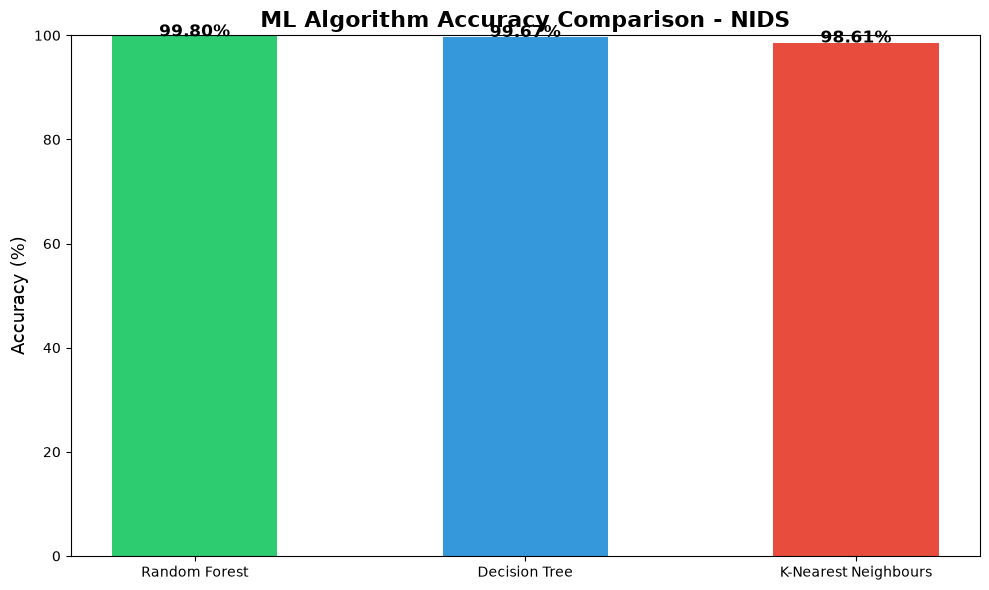

Chart saved!


In [15]:
# Visualise model comparison
models = ['Random Forest', 'Decision Tree', 'K-Nearest Neighbours']
accuracies = [rf_accuracy * 100, dt_accuracy * 100, knn_accuracy * 100]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#2ecc71', '#3498db', '#e74c3c'], width=0.5)
plt.title('ML Algorithm Accuracy Comparison - NIDS', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim([0, 100])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

RANDOM FOREST - DETAILED REPORT
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       185
buffer_overflow       1.00      0.33      0.50         9
      ftp_write       0.00      0.00      0.00         0
   guess_passwd       1.00      0.91      0.95        11
           imap       1.00      1.00      1.00         1
        ipsweep       0.99      0.99      0.99       733
           land       0.00      0.00      0.00         3
     loadmodule       0.00      0.00      0.00         0
       multihop       0.00      0.00      0.00         0
        neptune       1.00      1.00      1.00      8228
           nmap       0.98      0.99      0.99       313
         normal       1.00      1.00      1.00     13422
           perl       0.00      0.00      0.00         1
            phf       1.00      1.00      1.00         1
            pod       1.00      0.93      0.96        43
      portsweep       1.00      0.99      1.00       57

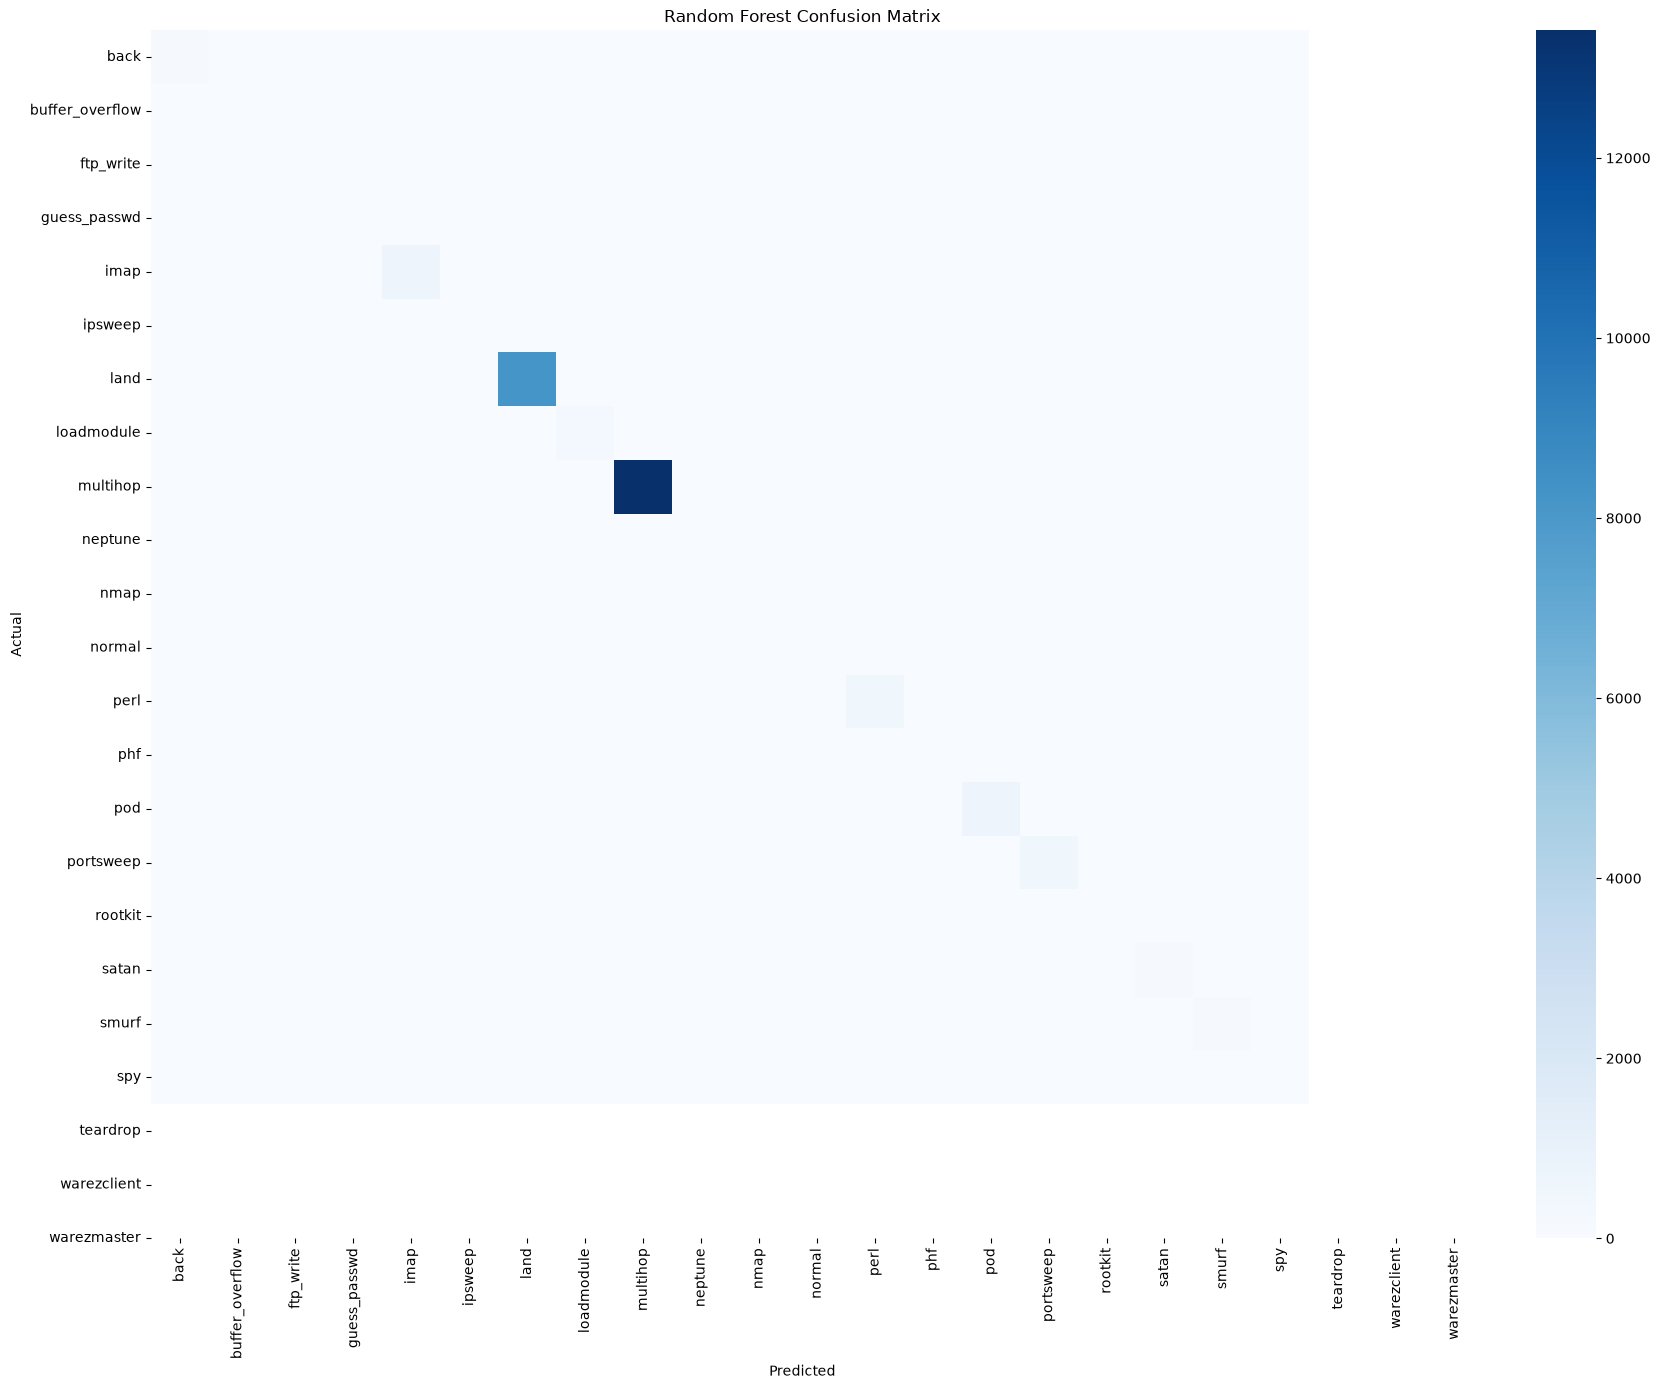

Confusion matrix saved!


In [16]:
# Detailed evaluation of Random Forest
print("=" * 60)
print("RANDOM FOREST - DETAILED REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    rf_pred,
    labels=range(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(18, 14))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("Confusion matrix saved!")

In [17]:
# Summary
print("=" * 50)
print("   NIDS PROJECT - FINAL SUMMARY")
print("=" * 50)
print(f"Dataset: NSL-KDD (125,973 samples)")
print(f"Features: 41 network traffic features")
print(f"")
print(f"MODEL PERFORMANCE:")
print(f"Random Forest    : {rf_accuracy*100:.2f}%")
print(f"Decision Tree    : {dt_accuracy*100:.2f}%")
print(f"K-Nearest Neighbours: {knn_accuracy*100:.2f}%")
print(f"")
print(f"Best Model: Random Forest")
print(f"Conclusion: ML can detect network intrusions")
print(f"with near-perfect accuracy!")
print("=" * 50)

   NIDS PROJECT - FINAL SUMMARY
Dataset: NSL-KDD (125,973 samples)
Features: 41 network traffic features

MODEL PERFORMANCE:
Random Forest    : 99.80%
Decision Tree    : 99.67%
K-Nearest Neighbours: 98.61%

Best Model: Random Forest
Conclusion: ML can detect network intrusions
with near-perfect accuracy!


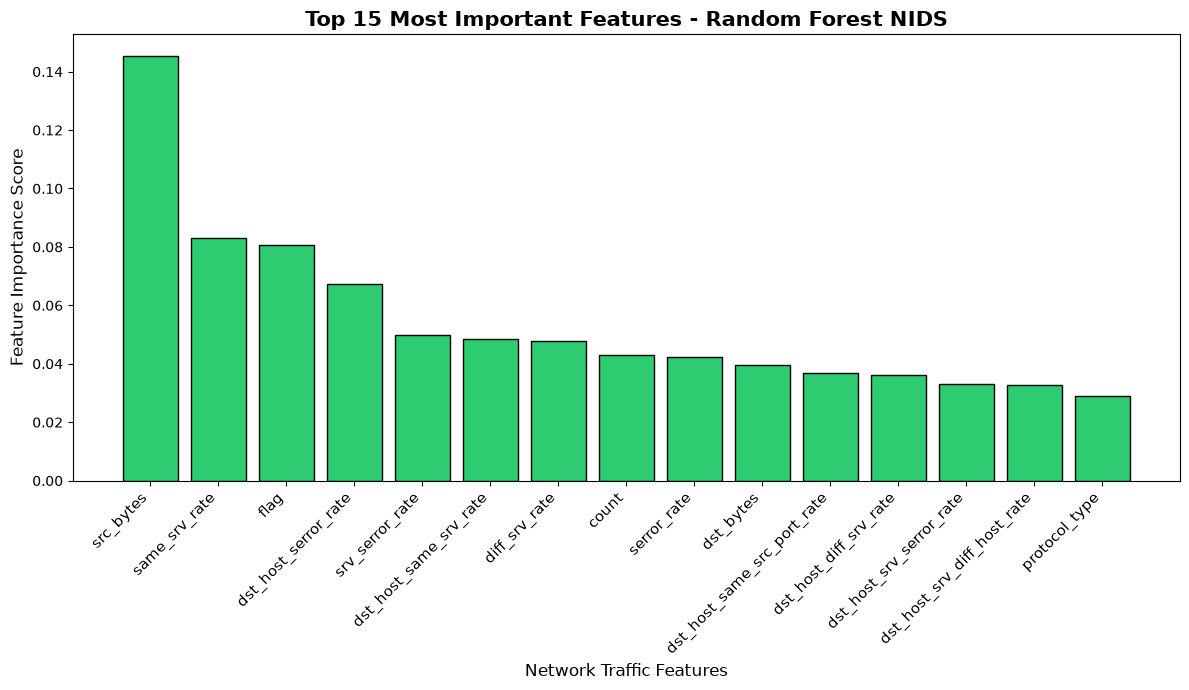

Feature importance chart saved!


In [18]:
# Feature Importance Chart
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(12, 7))
plt.title('Top 15 Most Important Features - Random Forest NIDS', 
          fontsize=15, fontweight='bold')
plt.bar(range(15), importances[indices], color='#2ecc71', edgecolor='black')
plt.xticks(range(15), [feature_names[i] for i in indices], 
           rotation=45, ha='right', fontsize=11)
plt.ylabel('Feature Importance Score', fontsize=12)
plt.xlabel('Network Traffic Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved!")

In [19]:
# Save the trained model for Flask
import joblib
joblib.dump(rf_model, 'nids_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [20]:
import os
print(os.getcwd())

c:\StdProject\NIDS_Project


In [21]:
import joblib

joblib.dump(label_encoder, "label_encoder.pkl")
print("Label encoder saved successfully!")

Label encoder saved successfully!


In [22]:
import os
import joblib

print("Current folder:", os.getcwd())

model = joblib.load("nids_model.pkl")

print("Model expects:", model.n_features_in_, "features")

Current folder: c:\StdProject\NIDS_Project
Model expects: 41 features


In [23]:
print("Protocol Encoder")
for i, v in enumerate(protocol_encoder.classes_):
    print(i, "=", v)

print("\nService Encoder")
for i, v in enumerate(service_encoder.classes_):
    print(i, "=", v)

print("\nFlag Encoder")
for i, v in enumerate(flag_encoder.classes_):
    print(i, "=", v)

Protocol Encoder
0 = icmp
1 = tcp
2 = udp

Service Encoder
0 = IRC
1 = X11
2 = Z39_50
3 = aol
4 = auth
5 = bgp
6 = courier
7 = csnet_ns
8 = ctf
9 = daytime
10 = discard
11 = domain
12 = domain_u
13 = echo
14 = eco_i
15 = ecr_i
16 = efs
17 = exec
18 = finger
19 = ftp
20 = ftp_data
21 = gopher
22 = harvest
23 = hostnames
24 = http
25 = http_2784
26 = http_443
27 = http_8001
28 = imap4
29 = iso_tsap
30 = klogin
31 = kshell
32 = ldap
33 = link
34 = login
35 = mtp
36 = name
37 = netbios_dgm
38 = netbios_ns
39 = netbios_ssn
40 = netstat
41 = nnsp
42 = nntp
43 = ntp_u
44 = other
45 = pm_dump
46 = pop_2
47 = pop_3
48 = printer
49 = private
50 = red_i
51 = remote_job
52 = rje
53 = shell
54 = smtp
55 = sql_net
56 = ssh
57 = sunrpc
58 = supdup
59 = systat
60 = telnet
61 = tftp_u
62 = tim_i
63 = time
64 = urh_i
65 = urp_i
66 = uucp
67 = uucp_path
68 = vmnet
69 = whois

Flag Encoder
0 = OTH
1 = REJ
2 = RSTO
3 = RSTOS0
4 = RSTR
5 = S0
6 = S1
7 = S2
8 = S3
9 = SF
10 = SH
